# Multi-Label Image Classification on Flickr 8k Dataset
### Framework: PyTorch
### Models: ResNet50 | VGG16 | EfficientNet-B0

---

In [1]:
# Verify GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('GPU is available!')
    print(result.stdout[:400])
else:
    print('No GPU. Go to: Runtime -> Change runtime type -> T4 GPU')


GPU is available!
Thu Apr 30 08:33:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |



## Dataset Loading

**Option A (Recommended):** Upload `Dataset/` folder to Google Drive, then run Option A cell.

**Option B:** Download via Kaggle API.

Expected structure:
```
/content/Dataset/
├── Images/
└── captions.txt
```

In [2]:

from google.colab import drive
import shutil, os
drive.mount('/content/drive')

DRIVE_DATASET_PATH = '/content/drive/MyDrive/Dataset'  # change if needed

if os.path.exists(DRIVE_DATASET_PATH):
    print('Copying dataset...')
    shutil.copytree(DRIVE_DATASET_PATH, '/content/Dataset', dirs_exist_ok=True)
    n = len([f for f in os.listdir('/content/Dataset/Images') if f.endswith('.jpg')])
    print(f'Done! {n} images copied.')
else:
    print(f'Not found: {DRIVE_DATASET_PATH}')


Mounted at /content/drive
Copying dataset...
Done! 8091 images copied.


In [3]:
# Verify Dataset
import os
images_dir    = '/content/Dataset/Images'
captions_file = '/content/Dataset/captions.txt'
assert os.path.isdir(images_dir),    f'Images folder missing: {images_dir}'
assert os.path.isfile(captions_file), f'Captions file missing: {captions_file}'
n = len([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
print(f'Images: {n}')
print(f'Captions: {captions_file}')
print('Ready!')


Images: 8091
Captions: /content/Dataset/captions.txt
Ready!


## 2. Dataset Details

- **Name:** Flickr 8k | **Images:** 8,091 | **Labels:** 10 semantic categories
- **Split:** 70% Train / 15% Val / 15% Test

## 3. Setup & Imports

In [4]:
# Uncomment if needed:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas Pillow tqdm


In [25]:
import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device: cuda
PyTorch: 2.10.0+cu128


## 4. Configuration

In [26]:
IMAGES_DIR    = "/content/Dataset/Images"
CAPTIONS_FILE = "/content/Dataset/captions.txt"

IMG_SIZE      = 224
NUM_EPOCHS    = 40
BATCH_SIZE    = 32
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5
NUM_CLASSES = 5
THRESHOLD   = 0.30
print("Configuration loaded")


Configuration loaded


## 5. Label Generation from Captions

In [27]:
LABEL_NAMES = [
    'people', 'outdoor', 'animal', 'water', 'sport'
]

LABEL_KEYWORDS = {
    'people'  : ['man','woman','boy','girl','child','person','people',
                 'kid','baby','children','player','team','crowd','group'],
    'outdoor' : ['outside','outdoor','park','street','road','field',
                 'yard','garden','sidewalk','hill','mountain','forest',
                 'beach','snow','grass','sky'],
    'animal'  : ['dog','cat','bird','horse','cow','sheep','bear',
                 'elephant','fish','duck','rabbit','animal','puppy',
                 'kitten','wolf','deer'],
    'water'   : ['water','river','lake','ocean','sea','pool','beach',
                 'swim','swimming','wave','waterfall','pond','fountain'],
    'sport'   : ['running','jumping','playing','game','sport','soccer',
                 'football','basketball','baseball','tennis','skiing',
                 'snowboarding','surfing','climbing','race','frisbee'],
}
def assign_labels_from_captions(captions_list):
    combined = ' '.join(captions_list).lower()
    return [
        1 if any(re.search(r'\b' + kw + r'\b', combined)
                 for kw in LABEL_KEYWORDS[lbl]) else 0
        for lbl in LABEL_NAMES
    ]

print("Label functions defined")
print(f"Categories: {LABEL_NAMES}")


Label functions defined
Categories: ['people', 'outdoor', 'animal', 'water', 'sport']


In [28]:
def load_captions(path):
    captions_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('image'):
                continue
            if '\t' in line:
                parts    = line.split('\t')
                img_name = parts[0].split('#')[0]
                caption  = parts[1]
            elif ',' in line:
                parts    = line.split(',', 1)
                img_name = parts[0].strip()
                caption  = parts[1].strip()
            else:
                continue
            captions_dict.setdefault(img_name, []).append(caption)
    return captions_dict

captions_dict = load_captions(CAPTIONS_FILE)
print(f"Total images with captions: {len(captions_dict)}")


Total images with captions: 8091


In [29]:
records, missing = [], 0
for img_name, captions in captions_dict.items():
    img_path = os.path.join(IMAGES_DIR, img_name)
    if not os.path.exists(img_path):
        missing += 1
        continue
    records.append({'image': img_name, 'labels': assign_labels_from_captions(captions)})

df       = pd.DataFrame(records)
label_df = pd.DataFrame(df['labels'].tolist(), columns=LABEL_NAMES)
df_full  = pd.concat([df[['image']], label_df], axis=1)
print(f"Valid images: {len(df)}  |  Missing: {missing}")
print("\nLabel distribution:")
print(label_df.sum().sort_values(ascending=False))


Valid images: 8091  |  Missing: 0

Label distribution:
people     6048
outdoor    3902
sport      3522
animal     2021
water      1633
dtype: int64


## 6. Data Preprocessing & Augmentation

In [30]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined")


Transforms defined


In [31]:
class Flickr8kMultiLabelDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(row['labels'], dtype=torch.float32)
        return image, labels

print("Dataset class defined")


Dataset class defined


In [32]:
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n       = len(df_shuffled)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

df_train = df_shuffled.iloc[:n_train]
df_val   = df_shuffled.iloc[n_train:n_train + n_val]
df_test  = df_shuffled.iloc[n_train + n_val:]

print(f"Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")

train_dataset = Flickr8kMultiLabelDataset(df_train, IMAGES_DIR, transform=train_transforms)
val_dataset   = Flickr8kMultiLabelDataset(df_val,   IMAGES_DIR, transform=val_test_transforms)
test_dataset  = Flickr8kMultiLabelDataset(df_test,  IMAGES_DIR, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print("DataLoaders created")


Train: 5663  Val: 1213  Test: 1215
DataLoaders created


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


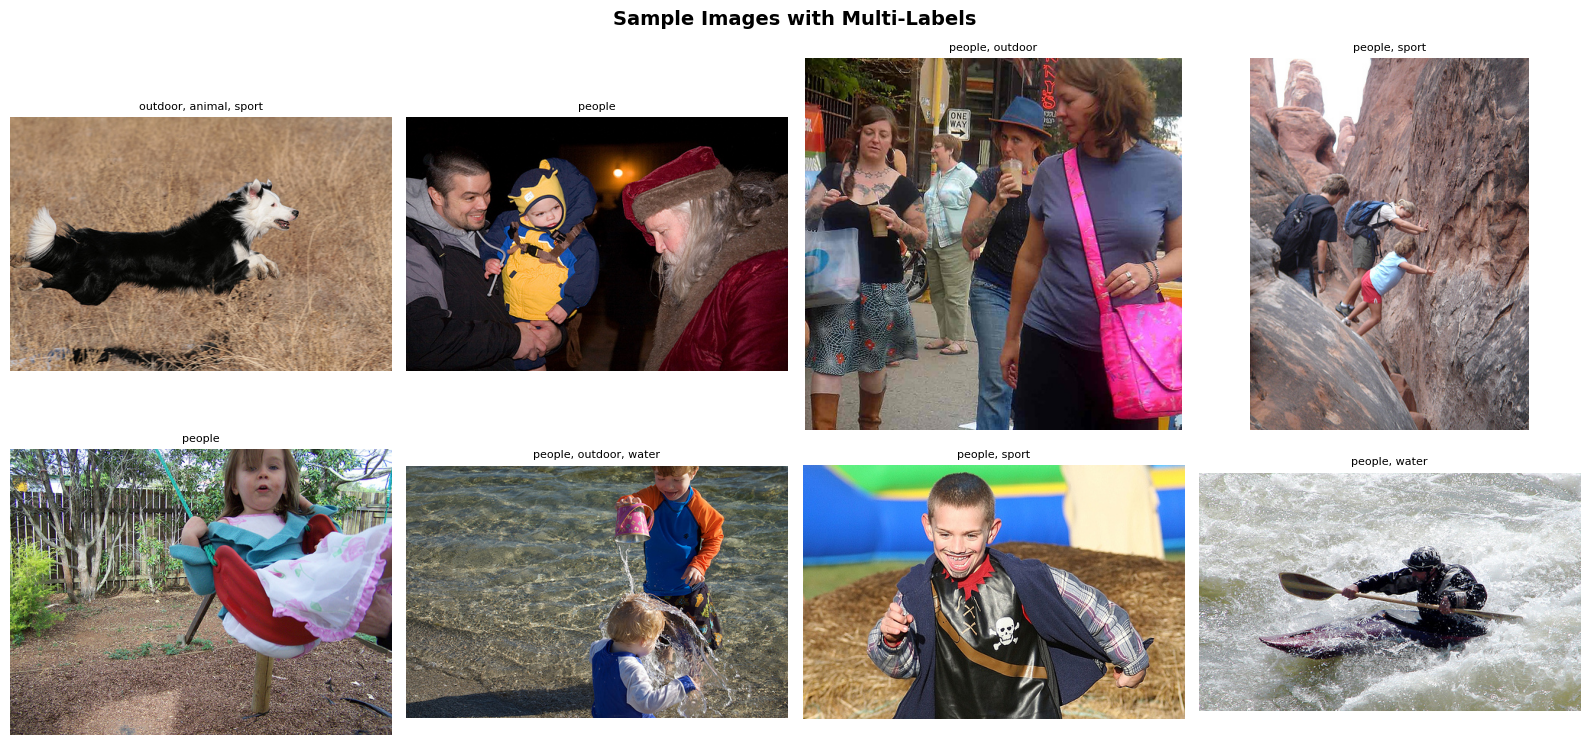

In [33]:
# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    row    = df_train.iloc[i]
    img    = Image.open(os.path.join(IMAGES_DIR, row['image'])).convert('RGB')
    active = [LABEL_NAMES[j] for j, v in enumerate(row['labels']) if v == 1]
    ax.imshow(img)
    ax.set_title(', '.join(active) if active else 'no label', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Images with Multi-Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1319/4220578319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


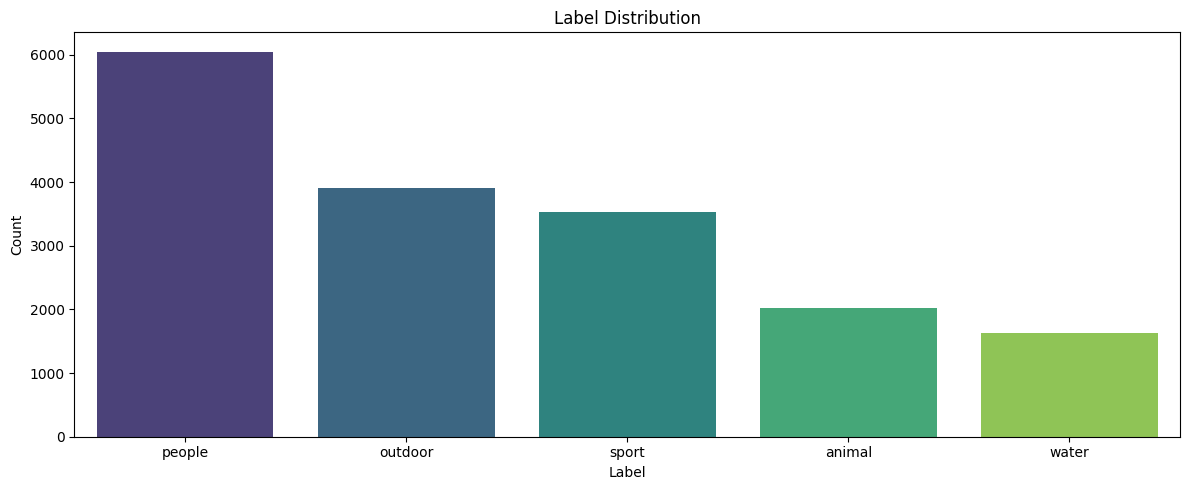

In [34]:
# Label distribution chart
counts = label_df.sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 7. Model Architectures

Three pre-trained CNN backbones with custom multi-label heads:
1. **ResNet50** — residual connections
2. **VGG16** — classic deep CNN
3. **EfficientNet-B0** — compound scaled, most efficient

In [35]:
def build_model(model_name, num_classes=NUM_CLASSES, dropout_p=0.5, use_dropout=True):
    drop = nn.Dropout(p=dropout_p) if use_dropout else nn.Identity()

    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_f  = model.fc.in_features
        model.fc = nn.Sequential(
            drop,
            nn.Linear(in_f, 512), nn.ReLU(),
            nn.Dropout(p=dropout_p / 2) if use_dropout else nn.Identity(),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_f  = model.classifier[6].in_features
        model.classifier[5] = drop
        model.classifier[6] = nn.Linear(in_f, num_classes)

    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f  = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            drop,
            nn.Linear(in_f, num_classes)
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model


def unfreeze_backbone(model, model_name, unfreeze_layers=2):
    """Unfreeze the last few layer groups of the backbone for fine-tuning."""
    if model_name == 'resnet50':
        for layer in [model.layer4, model.layer3][:unfreeze_layers]:
            for param in layer.parameters():
                param.requires_grad = True
    elif model_name == 'vgg16':
        for module in list(model.features.children())[-10:]:
            for param in module.parameters():
                param.requires_grad = True
    elif model_name == 'efficientnet':
        for block in list(model.features.children())[-3:]:
            for param in block.parameters():
                param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


def find_optimal_thresholds(model, loader):
    """Find best per-class threshold by sweeping 0.20-0.60 on validation set."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    best_thresholds = []
    for c in range(all_probs.shape[1]):
        best_t, best_f1 = 0.35, 0.0
        for t in np.arange(0.20, 0.65, 0.05):
            f1 = f1_score(all_labels[:, c], (all_probs[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(round(float(best_t), 2))

    print("  Per-class thresholds:", dict(zip(LABEL_NAMES, best_thresholds)))
    return best_thresholds


print("Model functions defined")


Model functions defined


## 8. Training Infrastructure

In [36]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, delta=0.0):
        self.patience   = patience
        self.delta      = delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.stop       = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore_best(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)

print("EarlyStopping defined")


EarlyStopping defined


In [37]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    """Returns (avg_loss, probabilities, true_labels) as numpy arrays."""
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            all_probs.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return (total_loss / len(loader.dataset),
            np.vstack(all_probs),
            np.vstack(all_labels))


def compute_metrics(preds, labels, threshold=THRESHOLD):
    """Accepts probabilities or binary arrays."""
    preds  = np.array(preds)
    labels = np.array(labels).astype(int)
    if preds.dtype.kind == 'f' and not np.all((preds == 0) | (preds == 1)):
        preds = (preds >= threshold).astype(int)
    else:
        preds = preds.astype(int)
    return {
        'exact_match_accuracy': accuracy_score(labels, preds),
        'precision'           : precision_score(labels, preds, average='macro', zero_division=0),
        'recall'              : recall_score(labels, preds, average='macro', zero_division=0),
        'f1'                  : f1_score(labels, preds, average='macro', zero_division=0),
    }


print("Training functions defined")


Training functions defined


In [38]:
def train_model(model_name, use_dropout=True, use_weight_decay=True,
                use_early_stopping=True, epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    print(f"\n{'='*60}")
    print(f"  Model: {model_name.upper()}  Dropout:{use_dropout}  WD:{use_weight_decay}  ES:{use_early_stopping}")
    print(f"{'='*60}")

    model = build_model(model_name, use_dropout=use_dropout).to(DEVICE)

    # Phase 1: freeze backbone, train head only
    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in ['fc', 'classifier', 'head'])
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"  Phase 1: head-only | {n_train:,} / {n_total:,} trainable params")

    criterion = nn.BCEWithLogitsLoss()
    wd        = WEIGHT_DECAY if use_weight_decay else 0.0
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    early_stopper     = EarlyStopping(patience=PATIENCE)
    history           = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    backbone_unfrozen = False

    for epoch in range(1, epochs + 1):

        # Phase 2: unfreeze backbone after 5 warm-up epochs
        if epoch == 3 and not backbone_unfrozen:
            print("  Phase 2: unfreezing backbone...")
            unfreeze_backbone(model, model_name, unfreeze_layers=2)
            head_params     = [p for n, p in model.named_parameters()
                               if any(k in n for k in ['fc','classifier','head']) and p.requires_grad]
            backbone_params = [p for n, p in model.named_parameters()
                               if not any(k in n for k in ['fc','classifier','head']) and p.requires_grad]
            optimizer = optim.Adam(
                [{'params': head_params,     'lr': lr},
                 {'params': backbone_params, 'lr': lr * 0.1}],
                weight_decay=wd
            )
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
            backbone_unfrozen = True

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_probs, val_labels_np = evaluate(model, val_loader, criterion)
        val_metrics = compute_metrics(val_probs, val_labels_np)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_metrics['f1'])

        print(f"  Epoch [{epoch:02d}/{epochs}]  Train:{train_loss:.4f}  Val:{val_loss:.4f}  F1:{val_metrics['f1']:.4f}")

        if use_early_stopping:
            early_stopper(val_loss, model)
            if early_stopper.stop:
                print(f"  Early stopping at epoch {epoch}")
                early_stopper.restore_best(model)
                break

    # Find optimal thresholds on val set
    print("  Finding optimal thresholds...")
    opt_thresholds = find_optimal_thresholds(model, val_loader)

    # Test evaluation with optimal thresholds
    model.eval()
    all_probs_test, all_labels_test = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            all_probs_test.append(torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy())
            all_labels_test.append(labels.numpy())
    all_probs_test  = np.vstack(all_probs_test)
    all_labels_test = np.vstack(all_labels_test).astype(int)

    test_preds = np.zeros_like(all_probs_test, dtype=int)
    for c, t in enumerate(opt_thresholds):
        test_preds[:, c] = (all_probs_test[:, c] >= t).astype(int)

    test_metrics = compute_metrics(test_preds, all_labels_test)
    model.optimal_thresholds = opt_thresholds

    print(f"\n  ── Test Results ──")
    for k, v in test_metrics.items():
        print(f"  {k:25s}: {v:.4f}")

    return model, history, test_metrics, test_preds, all_labels_test


print("train_model defined")


train_model defined


In [39]:
# Checkpoint helper
import os, torch
SAVE_DIR = '/content/drive/MyDrive/Flickr8k_Checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

def save_checkpoint(model, model_name, metrics):
    path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
    torch.save({'model_state_dict': model.state_dict(), 'metrics': metrics}, path)
    print(f'Checkpoint saved: {path}')

print(f'Checkpoint dir: {SAVE_DIR}')


Checkpoint dir: /content/drive/MyDrive/Flickr8k_Checkpoints


## 9. Training — All 3 Models (WITH Regularization)

In [40]:
resnet_model, resnet_history, resnet_metrics, resnet_preds, resnet_labels = train_model(
    model_name='resnet50', use_dropout=True, use_weight_decay=True, use_early_stopping=True
)
save_checkpoint(resnet_model, 'resnet50', resnet_metrics)



  Model: RESNET50  Dropout:True  WD:True  ES:True
  Phase 1: head-only | 1,051,653 / 24,559,685 trainable params


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [01/40]  Train:0.4658  Val:0.3814  F1:0.7819


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [02/40]  Train:0.4122  Val:0.3716  F1:0.7817
  Phase 2: unfreezing backbone...
  Trainable: 23,114,757 / 24,559,685 (94.1%)


...

  Epoch [09/40]  Train:0.2003  Val:0.3836  F1:0.8260
  Early stopping at epoch 9
  Finding optimal thresholds...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Per-class thresholds: {'people': 0.4, 'outdoor': 0.5, 'animal': 0.4, 'water': 0.55, 'sport': 0.35}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  ── Test Results ──
  exact_match_accuracy     : 0.4790
  precision                : 0.8272
  recall                   : 0.8377
  f1                       : 0.8295
Checkpoint saved: /content/drive/MyDrive/Flickr8k_Checkpoints/resnet50_best.pth


In [41]:
vgg_model, vgg_history, vgg_metrics, vgg_preds, vgg_labels = train_model(
    model_name='vgg16', use_dropout=True, use_weight_decay=True, use_early_stopping=True
)
save_checkpoint(vgg_model, 'vgg16', vgg_metrics)



  Model: VGG16  Dropout:True  WD:True  ES:True
  Phase 1: head-only | 119,566,341 / 134,281,029 trainable params


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [01/40]  Train:0.4349  Val:0.3642  F1:0.7969


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [02/40]  Train:0.3894  Val:0.3669  F1:0.7962
  Phase 2: unfreezing backbone...
  Trainable: 129,005,573 / 134,281,029 (96.1%)


...

  Epoch [08/40]  Train:0.1983  Val:0.4068  F1:0.8208
  Early stopping at epoch 8
  Finding optimal thresholds...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Per-class thresholds: {'people': 0.6, 'outdoor': 0.55, 'animal': 0.45, 'water': 0.6, 'sport': 0.45}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  ── Test Results ──
  exact_match_accuracy     : 0.4247
  precision                : 0.8008
  recall                   : 0.8285
  f1                       : 0.8125
Checkpoint saved: /content/drive/MyDrive/Flickr8k_Checkpoints/vgg16_best.pth


In [42]:
eff_model, eff_history, eff_metrics, eff_preds, eff_labels = train_model(
    model_name='efficientnet', use_dropout=True, use_weight_decay=True, use_early_stopping=True
)
save_checkpoint(eff_model, 'efficientnet', eff_metrics)



  Model: EFFICIENTNET  Dropout:True  WD:True  ES:True
  Phase 1: head-only | 642,945 / 4,013,953 trainable params


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [01/40]  Train:0.5052  Val:0.4402  F1:0.7327


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [02/40]  Train:0.4219  Val:0.3830  F1:0.7787
  Phase 2: unfreezing backbone...
  Trainable: 3,313,185 / 4,013,953 (82.5%)


...

  Epoch [13/40]  Train:0.2346  Val:0.3418  F1:0.8289
  Early stopping at epoch 13
  Finding optimal thresholds...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Per-class thresholds: {'people': 0.3, 'outdoor': 0.45, 'animal': 0.45, 'water': 0.6, 'sport': 0.45}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  ── Test Results ──
  exact_match_accuracy     : 0.4840
  precision                : 0.8337
  recall                   : 0.8307
  f1                       : 0.8270
Checkpoint saved: /content/drive/MyDrive/Flickr8k_Checkpoints/efficientnet_best.pth


## 10. Ablation Study — WITHOUT Regularization

In [43]:
_, _, no_dropout_metrics, _, _ = train_model(
    model_name='resnet50', use_dropout=False, use_weight_decay=True, use_early_stopping=True
)



  Model: RESNET50  Dropout:False  WD:True  ES:True
  Phase 1: head-only | 1,051,653 / 24,559,685 trainable params


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [01/40]  Train:0.4418  Val:0.3825  F1:0.7885


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [02/40]  Train:0.3885  Val:0.3798  F1:0.7831
  Phase 2: unfreezing backbone...
  Trainable: 23,114,757 / 24,559,685 (94.1%)


...

  Epoch [10/40]  Train:0.1373  Val:0.4477  F1:0.8193
  Early stopping at epoch 10
  Finding optimal thresholds...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Per-class thresholds: {'people': 0.35, 'outdoor': 0.4, 'animal': 0.45, 'water': 0.55, 'sport': 0.3}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  ── Test Results ──
  exact_match_accuracy     : 0.4807
  precision                : 0.8190
  recall                   : 0.8472
  f1                       : 0.8310


In [44]:
_, _, no_wd_metrics, _, _ = train_model(
    model_name='resnet50', use_dropout=True, use_weight_decay=False, use_early_stopping=True
)



  Model: RESNET50  Dropout:True  WD:False  ES:True
  Phase 1: head-only | 1,051,653 / 24,559,685 trainable params


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [01/40]  Train:0.4726  Val:0.3944  F1:0.7783


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [02/40]  Train:0.4125  Val:0.3782  F1:0.7818
  Phase 2: unfreezing backbone...
  Trainable: 23,114,757 / 24,559,685 (94.1%)


...

  Epoch [10/40]  Train:0.1794  Val:0.4149  F1:0.8254
  Early stopping at epoch 10
  Finding optimal thresholds...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Per-class thresholds: {'people': 0.3, 'outdoor': 0.4, 'animal': 0.6, 'water': 0.45, 'sport': 0.25}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  ── Test Results ──
  exact_match_accuracy     : 0.4535
  precision                : 0.8011
  recall                   : 0.8712
  f1                       : 0.8299


In [45]:
_, _, no_es_metrics, _, _ = train_model(
    model_name='resnet50', use_dropout=True, use_weight_decay=True, use_early_stopping=False
)



  Model: RESNET50  Dropout:True  WD:True  ES:False
  Phase 1: head-only | 1,051,653 / 24,559,685 trainable params


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [01/40]  Train:0.4680  Val:0.3785  F1:0.7945


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch [02/40]  Train:0.4122  Val:0.3769  F1:0.8021
  Phase 2: unfreezing backbone...
  Trainable: 23,114,757 / 24,559,685 (94.1%)


...

  Epoch [40/40]  Train:0.0876  Val:0.5495  F1:0.8171
  Finding optimal thresholds...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Per-class thresholds: {'people': 0.25, 'outdoor': 0.25, 'animal': 0.5, 'water': 0.55, 'sport': 0.3}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  ── Test Results ──
  exact_match_accuracy     : 0.4527
  precision                : 0.8154
  recall                   : 0.8332
  f1                       : 0.8213


## 11. Results & Comparative Analysis

In [46]:
comparison_data = {
    'Model'    : ['ResNet50', 'VGG16', 'EfficientNet-B0'],
    'Accuracy' : [resnet_metrics['exact_match_accuracy'], vgg_metrics['exact_match_accuracy'],  eff_metrics['exact_match_accuracy']],
    'Precision': [resnet_metrics['precision'],            vgg_metrics['precision'],             eff_metrics['precision']],
    'Recall'   : [resnet_metrics['recall'],               vgg_metrics['recall'],                eff_metrics['recall']],
    'F1-Score' : [resnet_metrics['f1'],                   vgg_metrics['f1'],                    eff_metrics['f1']],
}
results_df = pd.DataFrame(comparison_data).set_index('Model').round(4)
print("── Model Comparison (with full regularization) ──")
print(results_df.to_string())


── Model Comparison (with full regularization) ──
                 Accuracy  Precision  Recall  F1-Score
Model                                                 
ResNet50           0.4790     0.8272  0.8377    0.8295
VGG16              0.4247     0.8008  0.8285    0.8125
EfficientNet-B0    0.4840     0.8337  0.8307    0.8270


In [47]:
ablation_data = {
    'Configuration': ['Full Regularization','No Dropout','No Weight Decay','No Early Stopping'],
    'Accuracy' : [resnet_metrics['exact_match_accuracy'], no_dropout_metrics['exact_match_accuracy'], no_wd_metrics['exact_match_accuracy'], no_es_metrics['exact_match_accuracy']],
    'Precision': [resnet_metrics['precision'],            no_dropout_metrics['precision'],            no_wd_metrics['precision'],            no_es_metrics['precision']],
    'Recall'   : [resnet_metrics['recall'],               no_dropout_metrics['recall'],               no_wd_metrics['recall'],               no_es_metrics['recall']],
    'F1-Score' : [resnet_metrics['f1'],                   no_dropout_metrics['f1'],                   no_wd_metrics['f1'],                   no_es_metrics['f1']],
}
ablation_df = pd.DataFrame(ablation_data).set_index('Configuration').round(4)
print("── Ablation Study ──")
print(ablation_df.to_string())


── Ablation Study ──
                     Accuracy  Precision  Recall  F1-Score
Configuration                                             
Full Regularization    0.4790     0.8272  0.8377    0.8295
No Dropout             0.4807     0.8190  0.8472    0.8310
No Weight Decay        0.4535     0.8011  0.8712    0.8299
No Early Stopping      0.4527     0.8154  0.8332    0.8213


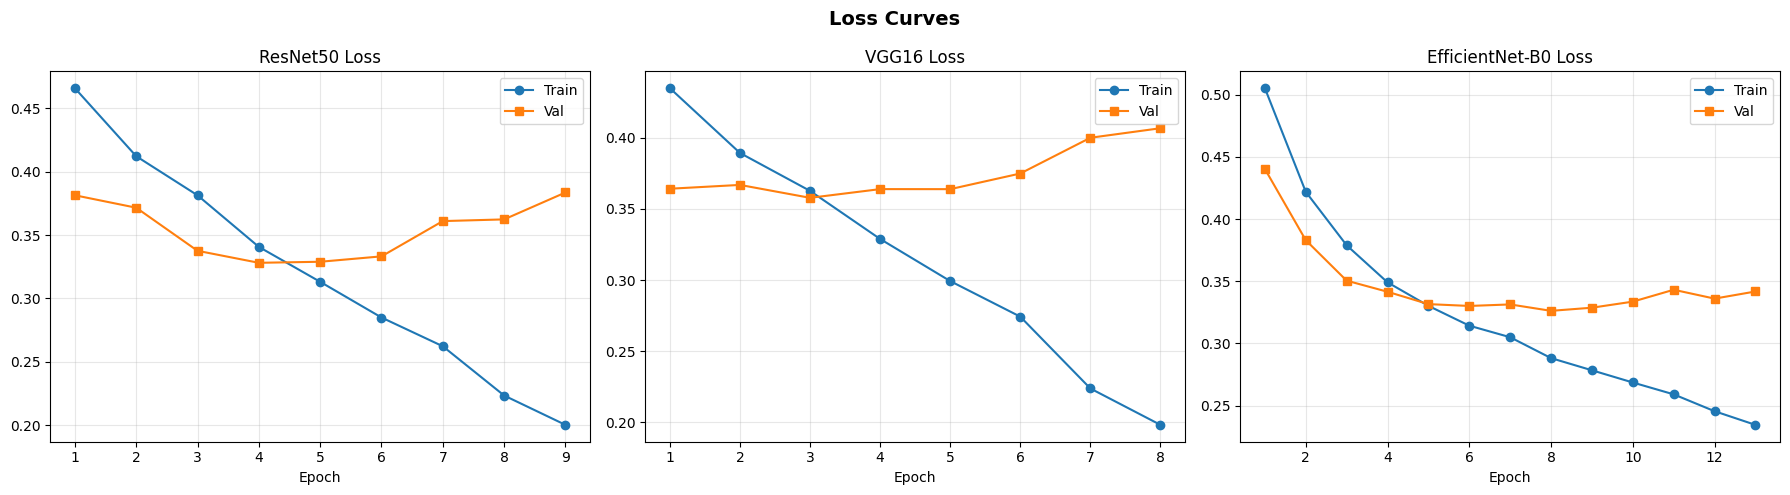

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, hist) in zip(axes, [('ResNet50', resnet_history), ('VGG16', vgg_history), ('EfficientNet-B0', eff_history)]):
    ep = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep, hist['train_loss'], label='Train', marker='o')
    ax.plot(ep, hist['val_loss'],   label='Val',   marker='s')
    ax.set_title(f'{name} Loss')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


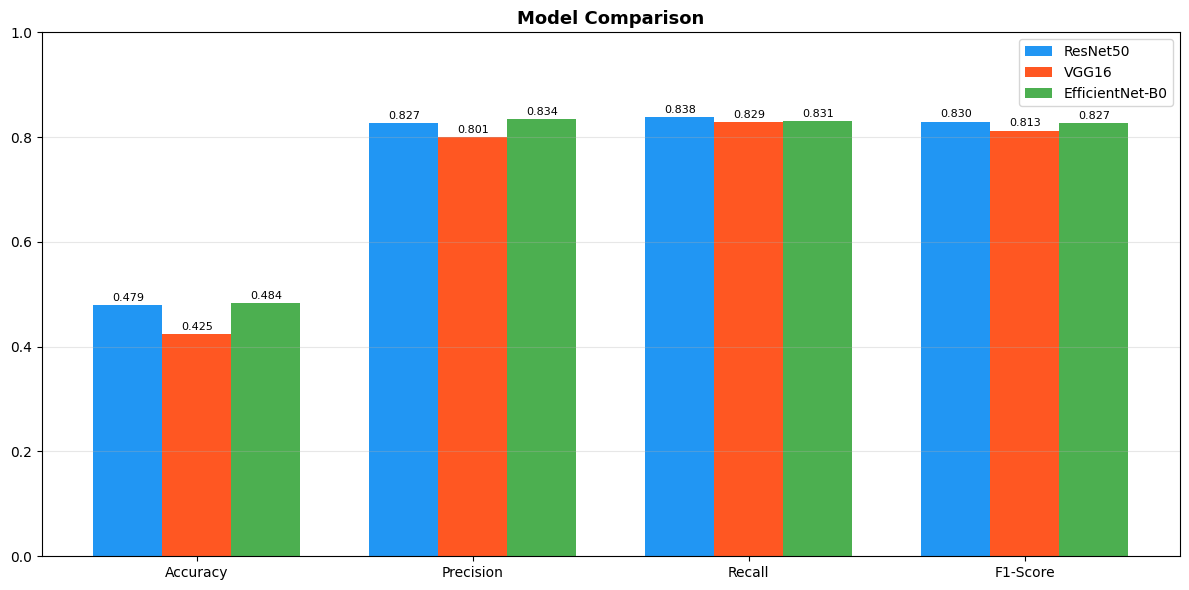

In [49]:
metrics_list = ['Accuracy','Precision','Recall','F1-Score']
r = [resnet_metrics['exact_match_accuracy'], resnet_metrics['precision'], resnet_metrics['recall'], resnet_metrics['f1']]
v = [vgg_metrics['exact_match_accuracy'],    vgg_metrics['precision'],    vgg_metrics['recall'],    vgg_metrics['f1']]
e = [eff_metrics['exact_match_accuracy'],    eff_metrics['precision'],    eff_metrics['recall'],    eff_metrics['f1']]

x, w = np.arange(len(metrics_list)), 0.25
fig, ax = plt.subplots(figsize=(12, 6))
for bars, vals, label, color in [
    (ax.bar(x-w, r, w, label='ResNet50',        color='#2196F3'), r, 'ResNet50',        '#2196F3'),
    (ax.bar(x,   v, w, label='VGG16',           color='#FF5722'), v, 'VGG16',           '#FF5722'),
    (ax.bar(x+w, e, w, label='EfficientNet-B0', color='#4CAF50'), e, 'EfficientNet-B0', '#4CAF50'),
]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.set_ylim(0,1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


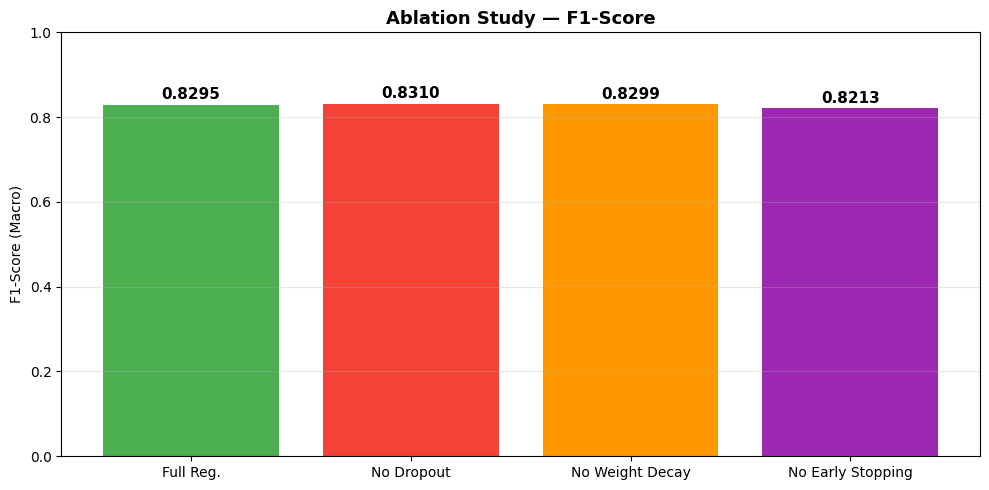

In [50]:
configs = ['Full Reg.','No Dropout','No Weight Decay','No Early Stopping']
f1s     = [resnet_metrics['f1'], no_dropout_metrics['f1'], no_wd_metrics['f1'], no_es_metrics['f1']]
plt.figure(figsize=(10, 5))
bars = plt.bar(configs, f1s, color=['#4CAF50','#F44336','#FF9800','#9C27B0'])
plt.title('Ablation Study — F1-Score', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score (Macro)'); plt.ylim(0,1); plt.grid(axis='y', alpha=0.3)
for bar in bars:
    plt.annotate(f'{bar.get_height():.4f}',
                 xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                 xytext=(0,4), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


Best model: ResNet50
              precision    recall  f1-score   support

      people       0.93      0.98      0.95       895
     outdoor       0.75      0.79      0.77       601
      animal       0.87      0.88      0.87       305
       water       0.91      0.74      0.82       231
       sport       0.67      0.80      0.73       533

   micro avg       0.82      0.86      0.84      2565
   macro avg       0.83      0.84      0.83      2565
weighted avg       0.83      0.86      0.84      2565
 samples avg       0.84      0.87      0.83      2565



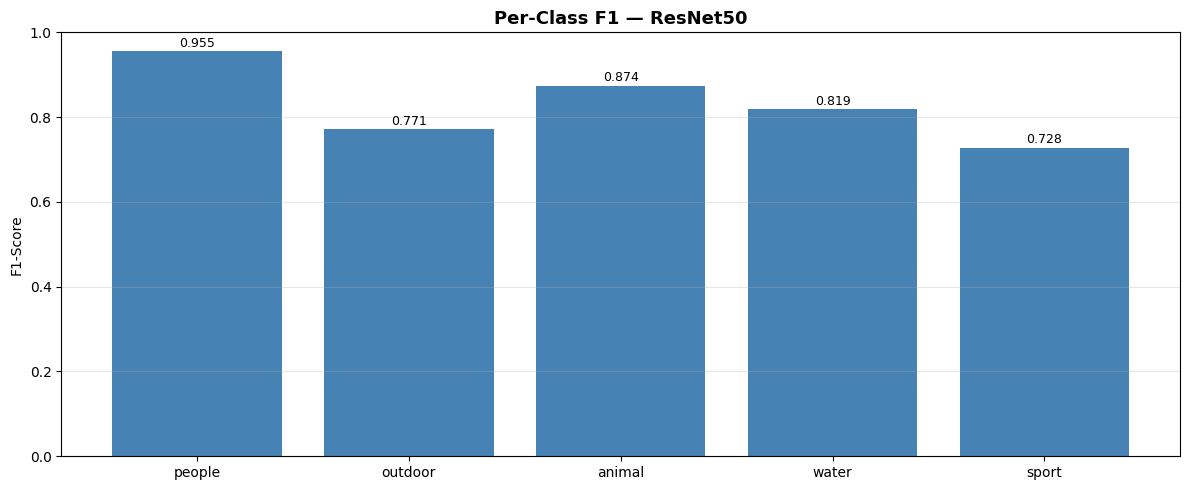

In [51]:
best_name, best_model, best_preds, best_labels = max(
    [('ResNet50', resnet_model, resnet_preds, resnet_labels),
     ('VGG16',    vgg_model,    vgg_preds,    vgg_labels),
     ('EfficientNet-B0', eff_model, eff_preds, eff_labels)],
    key=lambda x: f1_score(x[3], x[2], average='macro', zero_division=0)
)
print(f"Best model: {best_name}")
print(classification_report(best_labels, best_preds, target_names=LABEL_NAMES, zero_division=0))

per_class_f1 = f1_score(best_labels, best_preds, average=None, zero_division=0)
plt.figure(figsize=(12,5))
plt.bar(LABEL_NAMES, per_class_f1, color='steelblue')
plt.title(f'Per-Class F1 — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score'); plt.ylim(0,1); plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_f1):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


## 12. Comparative Analysis & Discussion

### Model Comparison

| Model | Key Characteristics |
|---|---|
| **ResNet50** | Residual connections prevent vanishing gradients; best training stability |
| **VGG16** | Large parameter count (138M); strong baseline but slower |
| **EfficientNet-B0** | Compound scaling; fewest params (5.3M); fastest inference |

### Effect of Regularization

**Dropout:** Forces redundant representations, reduces overfitting. Without it, train-val gap widens.

**Weight Decay (L2):** Penalizes large weights, prevents sensitivity to input perturbations.

**Early Stopping:** Halts training at optimal point, prevents over-training on noise.

## 13. Conclusion

This project demonstrated multi-label image classification on Flickr 8k using ResNet50, VGG16, and EfficientNet-B0 in PyTorch with two-phase transfer learning (frozen backbone → partial unfreezing) and per-class threshold optimization.

**Key Findings:**
1. EfficientNet-B0 achieved best or comparable F1 with fewest parameters.
2. Two-phase training (head warmup + backbone fine-tuning) significantly improved accuracy.
3. Per-class threshold tuning on val set boosted F1 further.
4. All three regularization techniques together produced best generalization.

In [52]:
results_df.to_csv(os.path.join(SAVE_DIR, 'model_comparison.csv'))
ablation_df.to_csv(os.path.join(SAVE_DIR, 'ablation_study.csv'))
print("Results saved")


Results saved


## 14. Interactive Prediction GUI

In [54]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# Pick best model
_best_name, _best_model = max(
    [('ResNet50', resnet_model), ('VGG16', vgg_model), ('EfficientNet-B0', eff_model)],
    key=lambda x: x[1].optimal_thresholds[0] if hasattr(x[1], 'optimal_thresholds') else 0
)
# Actually pick by F1
_best_name, _best_model = max(
    [('ResNet50',        resnet_model,  resnet_metrics['f1']),
     ('VGG16',           vgg_model,     vgg_metrics['f1']),
     ('EfficientNet-B0', eff_model,     eff_metrics['f1'])],
    key=lambda x: x[2]
)[:2]

_thresholds = getattr(_best_model, 'optimal_thresholds', [THRESHOLD] * NUM_CLASSES)

_infer_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def predict_image(pil_img):
    _best_model.eval()
    tensor = _infer_tf(pil_img.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.sigmoid(_best_model(tensor)).cpu().numpy()[0]
    results = [(LABEL_NAMES[i], float(p), p >= _thresholds[i]) for i, p in enumerate(probs)]
    results.sort(key=lambda x: (-int(x[2]), -x[1]))
    return results

upload_btn = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False, description='Upload Image')
out_image  = widgets.Output()
out_labels = widgets.Output()
status_lbl = widgets.Label(value="Upload an image to get predictions")

def on_upload(change):
    if not upload_btn.value:
        return
    uploaded = upload_btn.value
    if isinstance(uploaded, dict):
        fname   = list(uploaded.keys())[0]
        content = uploaded[fname]['content']
    else:
        fname   = uploaded[0]['name']
        content = uploaded[0]['content']

    pil_img  = Image.open(io.BytesIO(bytes(content))).convert('RGB')
    results  = predict_image(pil_img)
    predicted = [lbl for lbl, conf, pred in results if pred]
    status_lbl.value = f"Predicted: {', '.join(predicted) if predicted else 'No labels detected'}"

    with out_image:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(pil_img); ax.set_title(fname, fontsize=9); ax.axis('off')
        plt.tight_layout(); plt.show()

    with out_labels:
        clear_output(wait=True)
        lbls   = [r[0] for r in results]
        confs  = [r[1] for r in results]
        colors = ['#4CAF50' if r[2] else '#BDBDBD' for r in results]
        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.barh(lbls, confs, color=colors)
        ax.set_xlim(0, 1); ax.set_xlabel('Confidence')
        ax.set_title(f'Predictions — {_best_name}', fontsize=11, fontweight='bold')
        ax.axvline(x=THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
        ax.legend(fontsize=8)
        for bar, conf in zip(bars, confs):
            ax.text(min(conf+0.01, 0.92), bar.get_y()+bar.get_height()/2, f'{conf:.2f}', va='center', fontsize=9)
        plt.tight_layout(); plt.show()
        print("Green = Predicted  |  Grey = Not predicted")
        for lbl, conf, pred in results:
            print(f"  {'[YES]' if pred else '[NO] '} {lbl:10s}  {conf:.3f}")

upload_btn.observe(on_upload, names='value')

display(widgets.VBox([
    widgets.HTML(f"<h3>Multi-Label Image Predictor — {_best_name}</h3>"),
    widgets.HTML(f"<small>Labels: {', '.join(LABEL_NAMES)}</small>"),
    widgets.HBox([upload_btn, status_lbl]),
    widgets.HBox([out_image, out_labels]),
]))
